# 论文改进分析

本笔记本实现7个高优先级改进：
1. 分层一致性率分析
2. α因子分布与特征关联分析
3. 行业对评委vs粉丝的分别影响分析
4. 全赛季新系统模拟
5. 缺失值分布分析
6. 动态权重参数网格搜索
7. 跨赛季模型验证

In [121]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import cross_val_score
import warnings
warnings.filterwarnings('ignore')

# 设置绘图风格
plt.rcParams.update({
    'font.family': 'Arial',
    'font.size': 11,
    'axes.titlesize': 12,
    'axes.titleweight': 'bold',
    'axes.labelsize': 11,
    'axes.linewidth': 1.2,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'xtick.labelsize': 10,
    'ytick.labelsize': 10,
    'legend.fontsize': 10,
    'figure.dpi': 150,
    'savefig.dpi': 300,
    'savefig.bbox': 'tight',
})
plt.rcParams['font.sans-serif'] = ['Arial Unicode MS', 'SimHei', 'DejaVu Sans']
plt.rcParams['axes.unicode_minus'] = False

# 统一配色方案（学术风）
COLORS = {
    'primary': '#367DB0',           # 深蓝 - 主色
    'secondary': '#3D9F3C',         # 深绿 - 副色
    'light_blue': '#9DC7DD',        # 浅蓝
    'light_green': '#9ED17B',       # 浅绿
    'gray_blue': '#5385BD',         # 灰蓝
    'gray_green': '#519D78',        # 灰绿
    'orange': '#FF7F0E',            # 橙色
    'purple': '#9467BD',            # 紫色
    'red': '#D62728',               # 红色
    'neutral': '#7D8491',           # 灰色
    'fill_blue': '#DAE8FC',         # 浅蓝填充
    'fill_green': '#E8F5E9',        # 浅绿填充
    'fill_orange': '#FFF3E0',       # 浅橙填充
}

LINE_COLORS = {
    'line1': '#1F77B4',             # 深蓝
    'line2': '#FF7F0E',             # 橙色
    'line3': '#9467BD',             # 紫色
    'line4': '#2CA02C',             # 绿色
}

def add_legend(ax, loc='upper right', **kwargs):
    return ax.legend(loc=loc, frameon=True, fancybox=True, edgecolor='lightgray', **kwargs)

# 加载数据
data_long = pd.read_csv('../数据预处理/data_long_format.csv')
vote_estimates = pd.read_csv('../问题一/vote_estimates.csv')
verification = pd.read_csv('../问题一/verification_results.csv')
raw_data = pd.read_csv('../2026_MCM_Problem_C_Data.csv')

print(f"Long format data: {len(data_long)} rows")
print(f"Vote estimates: {len(vote_estimates)} rows")
print(f"Verification results: {len(verification)} rows")

Long format data: 2777 rows
Vote estimates: 2777 rows
Verification results: 274 rows


## 1. 分层一致性率分析

In [122]:
# 1.1 按投票方法分组
consistency_by_method = verification.groupby('method').agg({
    'is_consistent': ['sum', 'count', 'mean']
}).round(3)
consistency_by_method.columns = ['consistent_count', 'total_count', 'consistency_rate']
print("=== 按投票方法分层 ===")
print(consistency_by_method)
print()

=== 按投票方法分层 ===
            consistent_count  total_count  consistency_rate
method                                                     
percentage               193          201             0.960
rank                      28           73             0.384



In [123]:
# 1.2 按赛季阶段分组 (前期S1-17 vs 后期S18-34)
verification['season_phase'] = verification['season'].apply(lambda x: 'Early (S1-17)' if x <= 17 else 'Late (S18-34)')
consistency_by_phase = verification.groupby('season_phase').agg({
    'is_consistent': ['sum', 'count', 'mean']
}).round(3)
consistency_by_phase.columns = ['consistent_count', 'total_count', 'consistency_rate']
print("=== 按赛季阶段分层 ===")
print(consistency_by_phase)
print()

=== 按赛季阶段分层 ===
               consistent_count  total_count  consistency_rate
season_phase                                                  
Early (S1-17)               125          135             0.926
Late (S18-34)                96          139             0.691



In [124]:
# 1.3 按比赛阶段分组 (前期周1-5 vs 后期周6+)
verification['competition_stage'] = verification['week'].apply(lambda x: 'Early (W1-5)' if x <= 5 else 'Late (W6+)')
consistency_by_stage = verification.groupby('competition_stage').agg({
    'is_consistent': ['sum', 'count', 'mean']
}).round(3)
consistency_by_stage.columns = ['consistent_count', 'total_count', 'consistency_rate']
print("=== 按比赛阶段分层 ===")
print(consistency_by_stage)
print()

=== 按比赛阶段分层 ===
                   consistent_count  total_count  consistency_rate
competition_stage                                                 
Early (W1-5)                    109          133             0.820
Late (W6+)                      112          141             0.794



In [85]:
# 1.4 按选手数量分组 (选手多vs选手少)
verification['contestant_group'] = verification['n_contestants'].apply(
    lambda x: 'Many (>=8)' if x >= 8 else 'Few (<8)'
)
consistency_by_contestants = verification.groupby('contestant_group').agg({
    'is_consistent': ['sum', 'count', 'mean']
}).round(3)
consistency_by_contestants.columns = ['consistent_count', 'total_count', 'consistency_rate']
print("=== 按选手数量分层 ===")
print(consistency_by_contestants)
print()

=== 按选手数量分层 ===
                  consistent_count  total_count  consistency_rate
contestant_group                                                 
Few (<8)                        92          111             0.829
Many (>=8)                     129          163             0.791



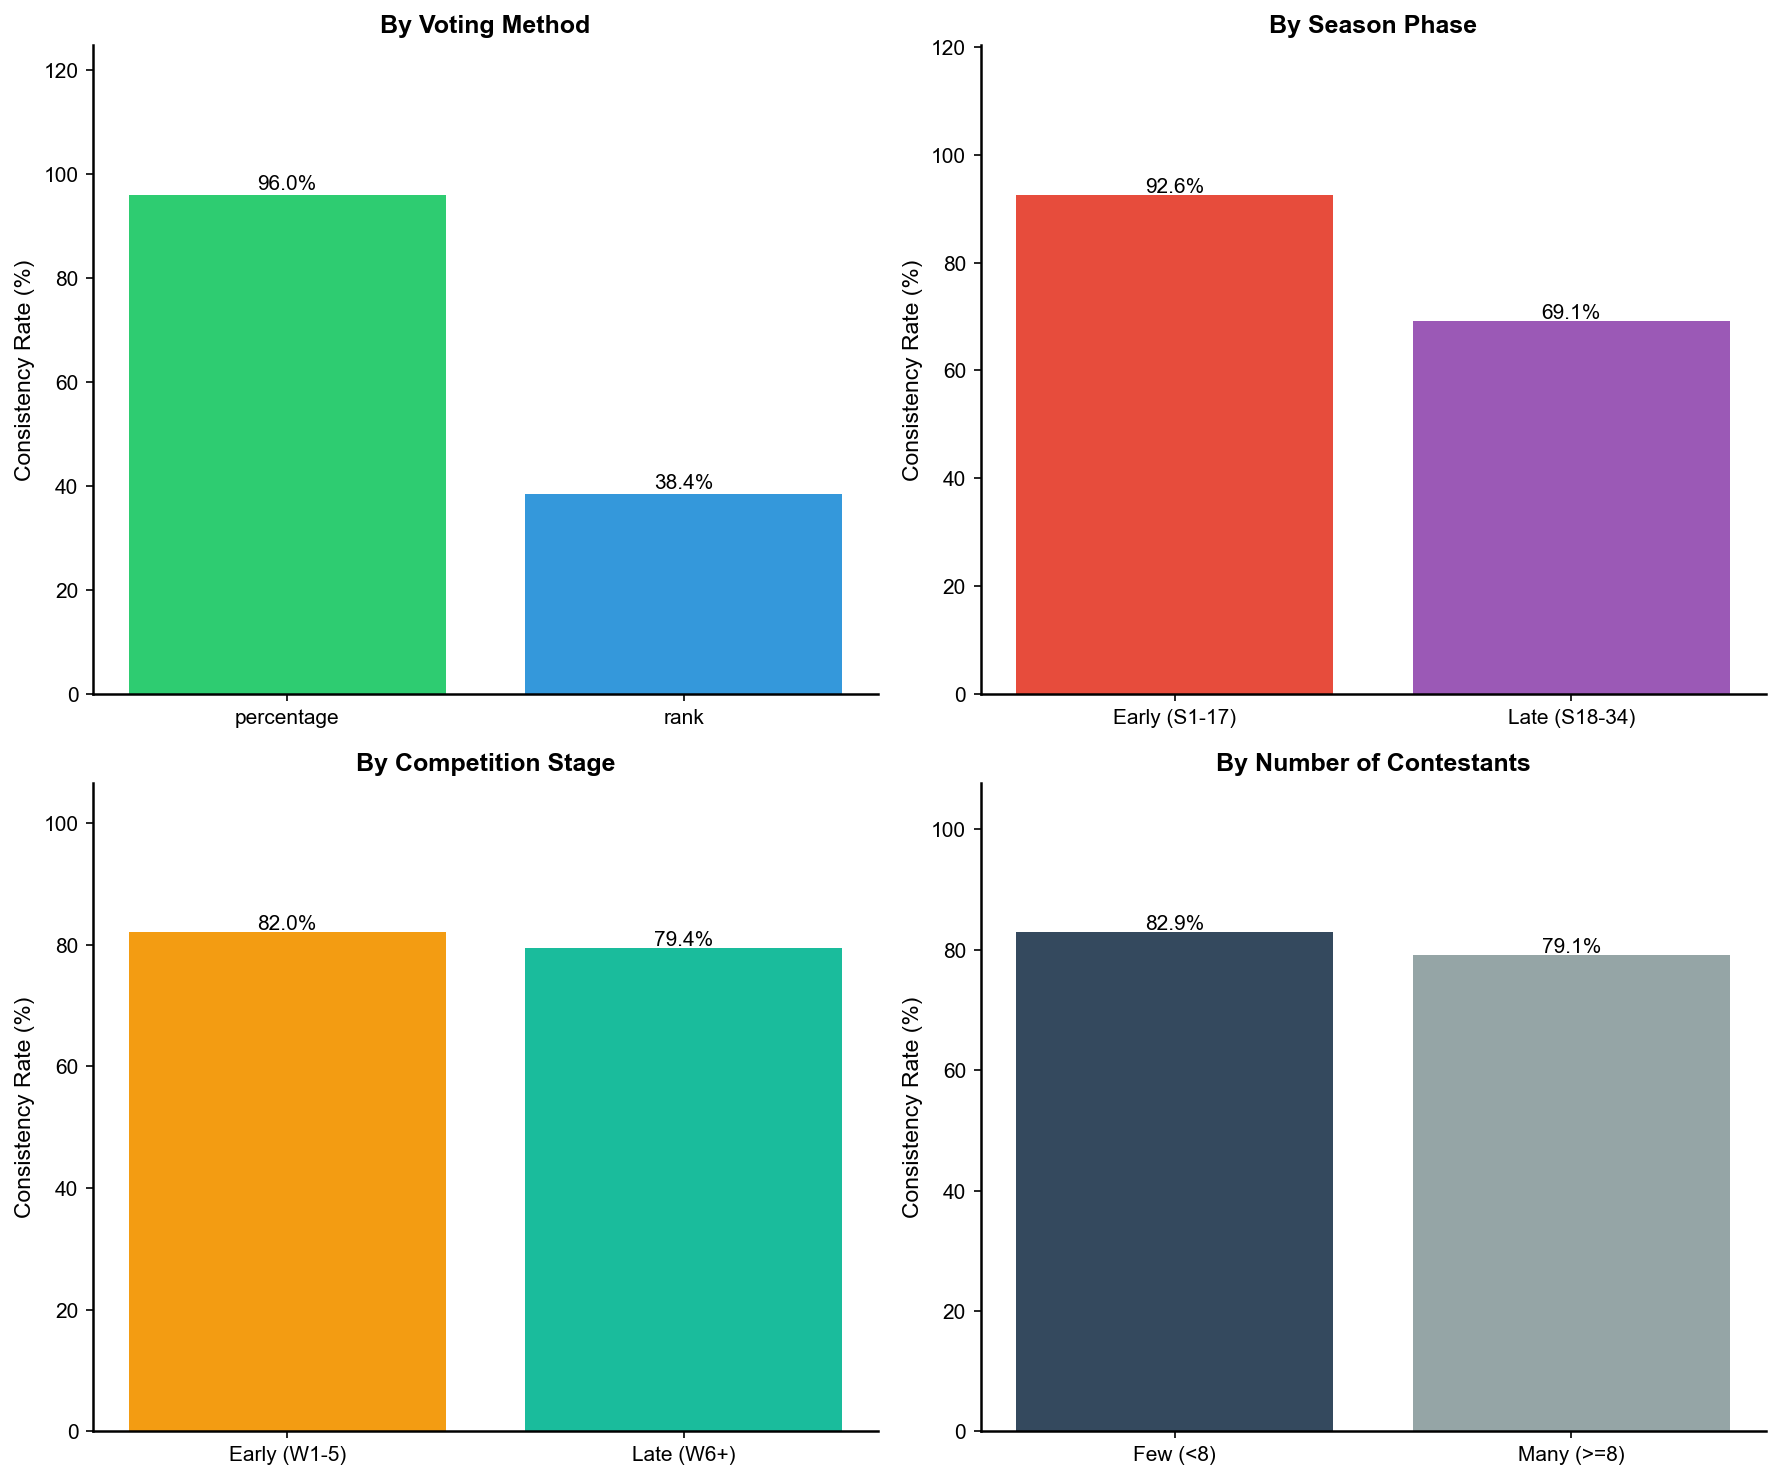

Figure saved: figures/IMP_fig1_stratified_consistency.pdf


In [86]:
# 1.5 绘制分层一致性率图
fig, axes = plt.subplots(2, 2, figsize=(12, 10))

# 按方法
ax1 = axes[0, 0]
methods = consistency_by_method.index.tolist()
rates = consistency_by_method['consistency_rate'].values * 100
bars1 = ax1.bar(methods, rates, color=['#2ecc71', '#3498db'])
ax1.set_ylabel('Consistency Rate (%)')
ax1.set_title('By Voting Method')
for bar, rate in zip(bars1, rates):
    ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1, f'{rate:.1f}%', 
             ha='center', fontsize=10)
ax1.set_ylim(0, max(rates) * 1.3)

# 按赛季阶段
ax2 = axes[0, 1]
phases = consistency_by_phase.index.tolist()
rates2 = consistency_by_phase['consistency_rate'].values * 100
bars2 = ax2.bar(phases, rates2, color=['#e74c3c', '#9b59b6'])
ax2.set_ylabel('Consistency Rate (%)')
ax2.set_title('By Season Phase')
for bar, rate in zip(bars2, rates2):
    ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5, f'{rate:.1f}%', 
             ha='center', fontsize=10)
ax2.set_ylim(0, max(rates2) * 1.3)

# 按比赛阶段
ax3 = axes[1, 0]
stages = consistency_by_stage.index.tolist()
rates3 = consistency_by_stage['consistency_rate'].values * 100
bars3 = ax3.bar(stages, rates3, color=['#f39c12', '#1abc9c'])
ax3.set_ylabel('Consistency Rate (%)')
ax3.set_title('By Competition Stage')
for bar, rate in zip(bars3, rates3):
    ax3.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5, f'{rate:.1f}%', 
             ha='center', fontsize=10)
ax3.set_ylim(0, max(rates3) * 1.3)

# 按选手数量
ax4 = axes[1, 1]
groups = consistency_by_contestants.index.tolist()
rates4 = consistency_by_contestants['consistency_rate'].values * 100
bars4 = ax4.bar(groups, rates4, color=['#34495e', '#95a5a6'])
ax4.set_ylabel('Consistency Rate (%)')
ax4.set_title('By Number of Contestants')
for bar, rate in zip(bars4, rates4):
    ax4.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5, f'{rate:.1f}%', 
             ha='center', fontsize=10)
ax4.set_ylim(0, max(rates4) * 1.3)

plt.tight_layout()
plt.savefig('figures/IMP_fig1_stratified_consistency.pdf', bbox_inches='tight')
plt.show()

print("Figure saved: figures/IMP_fig1_stratified_consistency.pdf")

In [87]:
# 1.6 保存分层一致性率数据
stratified_consistency = pd.DataFrame({
    'Category': ['By Method - Rank', 'By Method - Percentage',
                 'By Season - Early (S1-17)', 'By Season - Late (S18-34)',
                 'By Competition - Early (W1-5)', 'By Competition - Late (W6+)',
                 'By Contestants - Many (>=8)', 'By Contestants - Few (<8)'],
    'Consistent': [consistency_by_method.loc['rank', 'consistent_count'],
                   consistency_by_method.loc['percentage', 'consistent_count'],
                   consistency_by_phase.loc['Early (S1-17)', 'consistent_count'],
                   consistency_by_phase.loc['Late (S18-34)', 'consistent_count'],
                   consistency_by_stage.loc['Early (W1-5)', 'consistent_count'],
                   consistency_by_stage.loc['Late (W6+)', 'consistent_count'],
                   consistency_by_contestants.loc['Many (>=8)', 'consistent_count'],
                   consistency_by_contestants.loc['Few (<8)', 'consistent_count']],
    'Total': [consistency_by_method.loc['rank', 'total_count'],
              consistency_by_method.loc['percentage', 'total_count'],
              consistency_by_phase.loc['Early (S1-17)', 'total_count'],
              consistency_by_phase.loc['Late (S18-34)', 'total_count'],
              consistency_by_stage.loc['Early (W1-5)', 'total_count'],
              consistency_by_stage.loc['Late (W6+)', 'total_count'],
              consistency_by_contestants.loc['Many (>=8)', 'total_count'],
              consistency_by_contestants.loc['Few (<8)', 'total_count']],
    'Rate': [consistency_by_method.loc['rank', 'consistency_rate'],
             consistency_by_method.loc['percentage', 'consistency_rate'],
             consistency_by_phase.loc['Early (S1-17)', 'consistency_rate'],
             consistency_by_phase.loc['Late (S18-34)', 'consistency_rate'],
             consistency_by_stage.loc['Early (W1-5)', 'consistency_rate'],
             consistency_by_stage.loc['Late (W6+)', 'consistency_rate'],
             consistency_by_contestants.loc['Many (>=8)', 'consistency_rate'],
             consistency_by_contestants.loc['Few (<8)', 'consistency_rate']]
})
stratified_consistency.to_csv('stratified_consistency.csv', index=False)
print(stratified_consistency)

                        Category  Consistent  Total   Rate
0               By Method - Rank          28     73  0.384
1         By Method - Percentage         193    201  0.960
2      By Season - Early (S1-17)         125    135  0.926
3      By Season - Late (S18-34)          96    139  0.691
4  By Competition - Early (W1-5)         109    133  0.820
5    By Competition - Late (W6+)         112    141  0.794
6    By Contestants - Many (>=8)         129    163  0.791
7      By Contestants - Few (<8)          92    111  0.829


## 2. α因子分布与特征关联分析

In [88]:
# 2.1 合并投票估算与选手特征
# 获取选手特征（每个选手取第一条记录）
contestant_features = data_long.groupby('celebrity_name').first()[[
    'celebrity_industry', 'celebrity_age_during_season', 'placement', 'is_controversial'
]].reset_index()

# 计算每个选手的平均α因子
alpha_by_contestant = vote_estimates.groupby('celebrity_name').agg({
    'popularity_factor': 'mean',
    'estimated_vote_share': 'mean',
    'total_score': 'mean'
}).reset_index()
alpha_by_contestant.columns = ['celebrity_name', 'mean_alpha', 'mean_vote_share', 'mean_judge_score']

# 合并
alpha_features = alpha_by_contestant.merge(contestant_features, on='celebrity_name', how='left')
print(f"Combined data: {len(alpha_features)} contestants")
alpha_features.head()

Combined data: 408 contestants


,celebrity_name,mean_alpha,mean_vote_share,mean_judge_score,celebrity_industry,celebrity_age_during_season,placement,is_controversial
0,AJ McLean,0.000000,0.091699,23.444422,Singer/Rapper,42,7,False
1,Aaron Carter,-0.001516,0.111888,25.812463,Singer/Rapper,21,5,False
2,Adam Carolla,-0.000499,0.078763,18.500000,Radio Personality,43,9,False
3,Adam Rippon,-0.002497,0.197926,32.750000,Athlete,28,1,False
4,Adrian Peterson,0.000000,0.073713,19.000000,Athlete,38,11,False


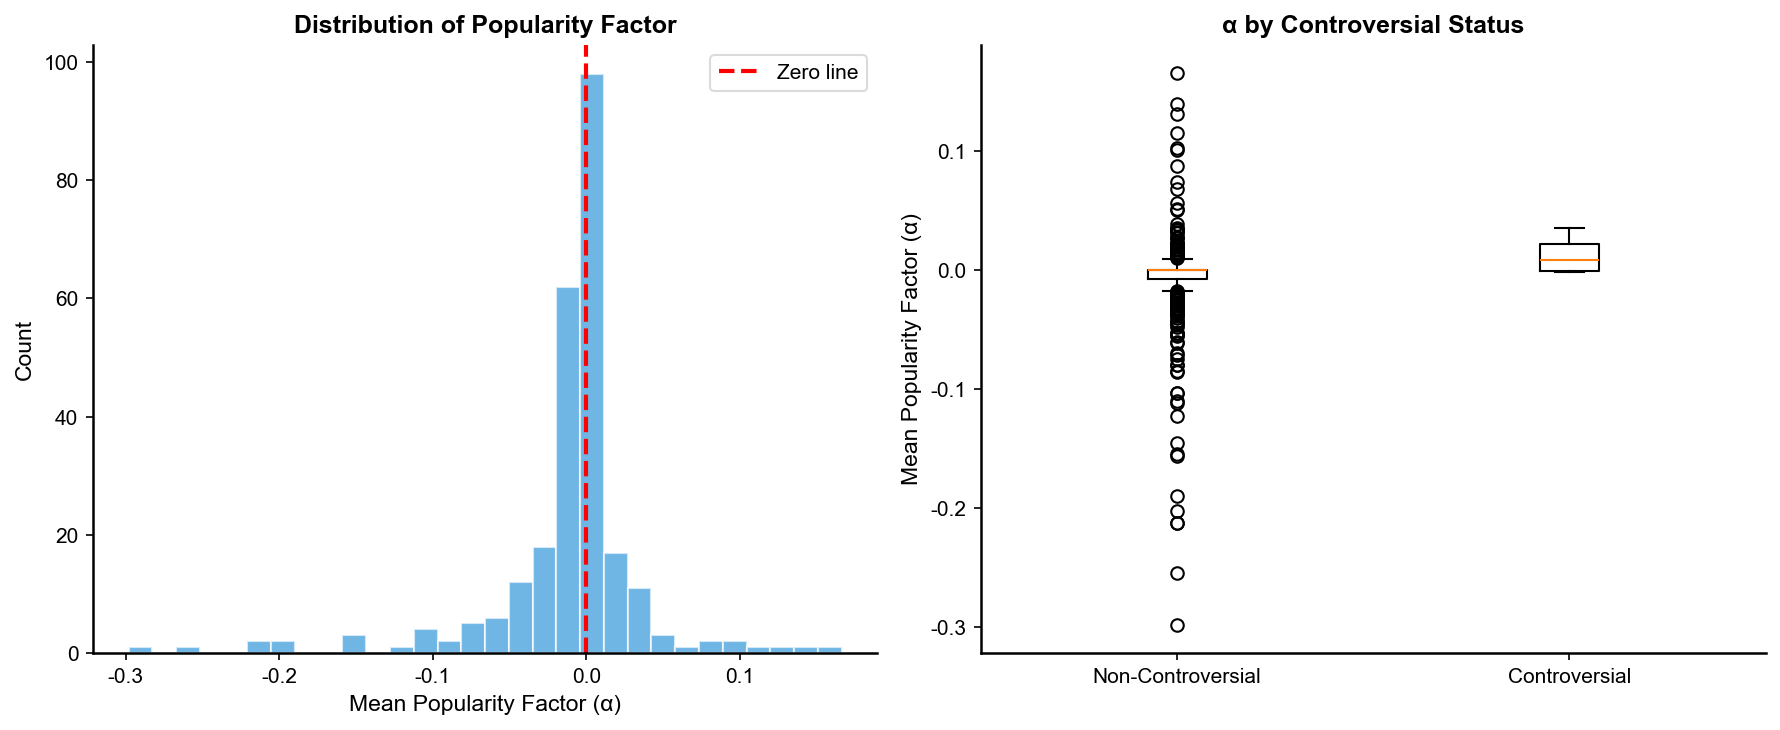

In [89]:
# 2.2 α因子分布直方图
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# 左图：α因子分布
ax1 = axes[0]
# 过滤掉接近0的值，只看有意义的α
alpha_nonzero = alpha_features[abs(alpha_features['mean_alpha']) > 1e-6]['mean_alpha']
ax1.hist(alpha_nonzero, bins=30, color='#3498db', edgecolor='white', alpha=0.7)
ax1.axvline(x=0, color='red', linestyle='--', linewidth=2, label='Zero line')
ax1.set_xlabel('Mean Popularity Factor (α)')
ax1.set_ylabel('Count')
ax1.set_title('Distribution of Popularity Factor')
ax1.legend(loc='upper right', frameon=True, fancybox=True, edgecolor='lightgray')

# 右图：争议vs非争议选手的α
ax2 = axes[1]
controversial = alpha_features[alpha_features['is_controversial'] == True]['mean_alpha']
non_controversial = alpha_features[alpha_features['is_controversial'] == False]['mean_alpha']
ax2.boxplot([non_controversial.dropna(), controversial.dropna()], 
            labels=['Non-Controversial', 'Controversial'])
ax2.set_ylabel('Mean Popularity Factor (α)')
ax2.set_title('α by Controversial Status')

plt.tight_layout()
plt.savefig('figures/IMP_fig2_alpha_distribution.pdf', bbox_inches='tight')
plt.show()

In [90]:
# 2.3 按行业分析α因子
alpha_by_industry = alpha_features.groupby('celebrity_industry').agg({
    'mean_alpha': ['mean', 'std', 'count'],
    'mean_vote_share': 'mean',
    'placement': 'mean'
}).round(4)
alpha_by_industry.columns = ['alpha_mean', 'alpha_std', 'count', 'vote_share_mean', 'placement_mean']
alpha_by_industry = alpha_by_industry.sort_values('alpha_mean', ascending=False)
print("=== α因子按行业分布 ===")
print(alpha_by_industry)

=== α因子按行业分布 ===
                          alpha_mean  alpha_std  count  vote_share_mean  \
celebrity_industry                                                        
Astronaut                     0.1662        NaN      1           0.0749   
Entrepreneur                  0.0418     0.0621      4           0.0789   
Military                      0.0220        NaN      1           0.1360   
Racing Driver                 0.0100     0.0217      3           0.1264   
Politician                    0.0098     0.0184      3           0.0713   
TV Personality                0.0018     0.0322     65           0.1032   
Motivational Speaker          0.0010        NaN      1           0.1438   
Conservationist               0.0000        NaN      1           0.1218   
Con artist                    0.0000        NaN      1           0.0693   
Fitness Instructor            0.0000        NaN      1           0.1071   
Magician                      0.0000        NaN      1           0.0665   
Social m

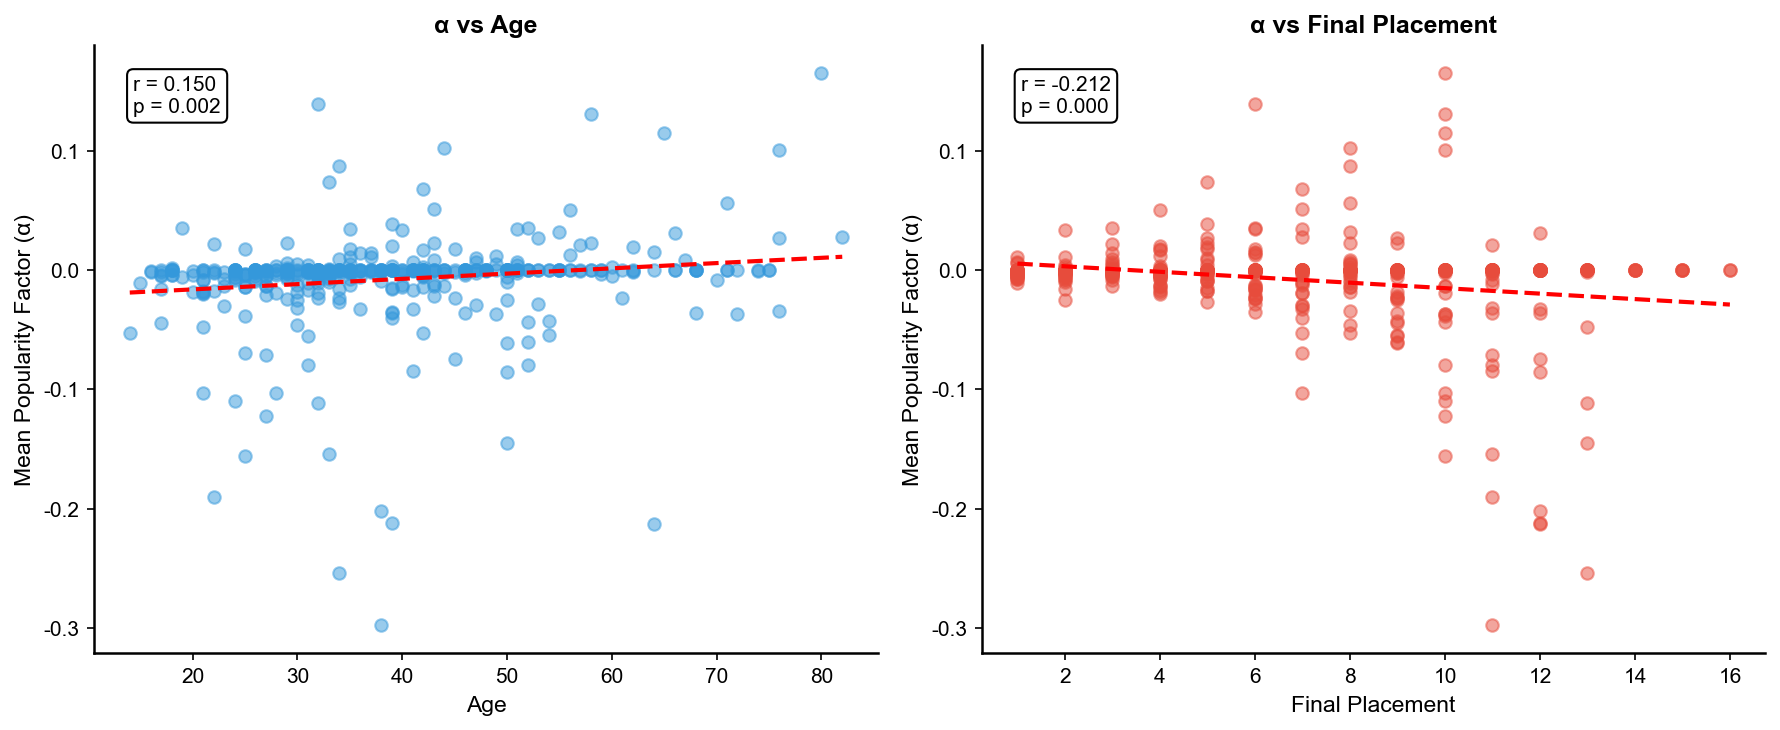

In [91]:
# 2.4 α因子与年龄、排名的相关性
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# α vs 年龄
ax1 = axes[0]
valid_data = alpha_features.dropna(subset=['mean_alpha', 'celebrity_age_during_season'])
ax1.scatter(valid_data['celebrity_age_during_season'], valid_data['mean_alpha'], 
            alpha=0.5, c='#3498db')
# 拟合线
z = np.polyfit(valid_data['celebrity_age_during_season'], valid_data['mean_alpha'], 1)
p = np.poly1d(z)
x_line = np.linspace(valid_data['celebrity_age_during_season'].min(), 
                     valid_data['celebrity_age_during_season'].max(), 100)
ax1.plot(x_line, p(x_line), 'r--', linewidth=2)
r, pval = stats.pearsonr(valid_data['celebrity_age_during_season'], valid_data['mean_alpha'])
ax1.text(0.05, 0.95, f'r = {r:.3f}\np = {pval:.3f}', transform=ax1.transAxes, 
         verticalalignment='top', fontsize=10, bbox=dict(boxstyle='round', facecolor='white'))
ax1.set_xlabel('Age')
ax1.set_ylabel('Mean Popularity Factor (α)')
ax1.set_title('α vs Age')

# α vs 最终排名
ax2 = axes[1]
valid_data2 = alpha_features.dropna(subset=['mean_alpha', 'placement'])
ax2.scatter(valid_data2['placement'], valid_data2['mean_alpha'], 
            alpha=0.5, c='#e74c3c')
# 添加拟合线
z2 = np.polyfit(valid_data2['placement'], valid_data2['mean_alpha'], 1)
p2 = np.poly1d(z2)
x_line2 = np.linspace(valid_data2['placement'].min(), valid_data2['placement'].max(), 100)
ax2.plot(x_line2, p2(x_line2), 'r--', linewidth=2)
r2, pval2 = stats.pearsonr(valid_data2['placement'], valid_data2['mean_alpha'])
ax2.text(0.05, 0.95, f'r = {r2:.3f}\np = {pval2:.3f}', transform=ax2.transAxes, 
         verticalalignment='top', fontsize=10, bbox=dict(boxstyle='round', facecolor='white'))
ax2.set_xlabel('Final Placement')
ax2.set_ylabel('Mean Popularity Factor (α)')
ax2.set_title('α vs Final Placement')

plt.tight_layout()
plt.savefig('figures/IMP_fig2_alpha_correlations.pdf', bbox_inches='tight')
plt.show()

In [92]:
# 2.5 保存α因子分析数据
alpha_analysis = alpha_features[['celebrity_name', 'celebrity_industry', 
                                  'celebrity_age_during_season', 'placement',
                                  'mean_alpha', 'mean_vote_share', 'is_controversial']]
alpha_analysis.to_csv('alpha_factor_analysis.csv', index=False)
alpha_by_industry.to_csv('alpha_by_industry.csv')
print("Saved: alpha_factor_analysis.csv, alpha_by_industry.csv")

Saved: alpha_factor_analysis.csv, alpha_by_industry.csv


## 3. 行业对评委vs粉丝的分别影响分析

In [93]:
# 3.1 合并评委分数与粉丝投票估算
# 按选手-周合并
merged = data_long.merge(
    vote_estimates[['celebrity_name', 'season', 'week', 'estimated_vote_share', 'popularity_factor']],
    on=['celebrity_name', 'season', 'week'],
    how='left'
)
print(f"Merged data: {len(merged)} rows")

Merged data: 2777 rows


In [94]:
# 3.2 按行业计算评委分数和粉丝投票的平均值
industry_impact = merged.groupby('celebrity_industry').agg({
    'total_score': 'mean',
    'avg_score': 'mean',
    'estimated_vote_share': 'mean',
    'judge_rank': 'mean',
    'placement': 'mean',
    'celebrity_name': 'nunique'
}).round(3)
industry_impact.columns = ['avg_total_score', 'avg_judge_score', 'avg_vote_share', 
                           'avg_judge_rank', 'avg_placement', 'n_contestants']
industry_impact = industry_impact.sort_values('avg_placement')
print("=== 行业对评委分数vs粉丝投票的影响 ===")
print(industry_impact)

=== 行业对评委分数vs粉丝投票的影响 ===
                          avg_total_score  avg_judge_score  avg_vote_share  \
celebrity_industry                                                           
Conservationist                    30.197            8.838           0.122   
Social media personality           30.136            8.792           0.121   
Producer                           26.364            8.788           0.121   
Musician                           28.650            8.883           0.138   
Military                           26.727            8.212           0.136   
Fitness Instructor                 31.050            7.912           0.107   
Motivational Speaker               32.050            8.012           0.144   
Sports Broadcaster                 23.864            7.955           0.157   
Racing Driver                      28.187            8.240           0.131   
Athlete                            26.243            7.980           0.127   
Social Media Personality           32.4

In [95]:
# 3.3 标准化后比较
from sklearn.preprocessing import StandardScaler

# 对每个行业计算标准化分数
industry_std = industry_impact.copy()
scaler = StandardScaler()
cols_to_scale = ['avg_total_score', 'avg_vote_share']
industry_std[['score_z', 'vote_z']] = scaler.fit_transform(industry_std[cols_to_scale])
industry_std['score_vote_gap'] = industry_std['score_z'] - industry_std['vote_z']
print("=== 标准化分数差异 (正值=评委分数相对更高) ===")
print(industry_std[['avg_total_score', 'avg_vote_share', 'score_z', 'vote_z', 'score_vote_gap']])

=== 标准化分数差异 (正值=评委分数相对更高) ===
                          avg_total_score  avg_vote_share   score_z    vote_z  \
celebrity_industry                                                              
Conservationist                    30.197           0.122  1.085407  0.555107   
Social media personality           30.136           0.121  1.073834  0.516620   
Producer                           26.364           0.121  0.358212  0.516620   
Musician                           28.650           0.138  0.791911  1.170907   
Military                           26.727           0.136  0.427080  1.093932   
Fitness Instructor                 31.050           0.107  1.247237 -0.022204   
Motivational Speaker               32.050           0.144  1.436957  1.401831   
Sports Broadcaster                 23.864           0.157 -0.116086  1.902168   
Racing Driver                      28.187           0.131  0.704071  0.901494   
Athlete                            26.243           0.127  0.335256  0.747545  

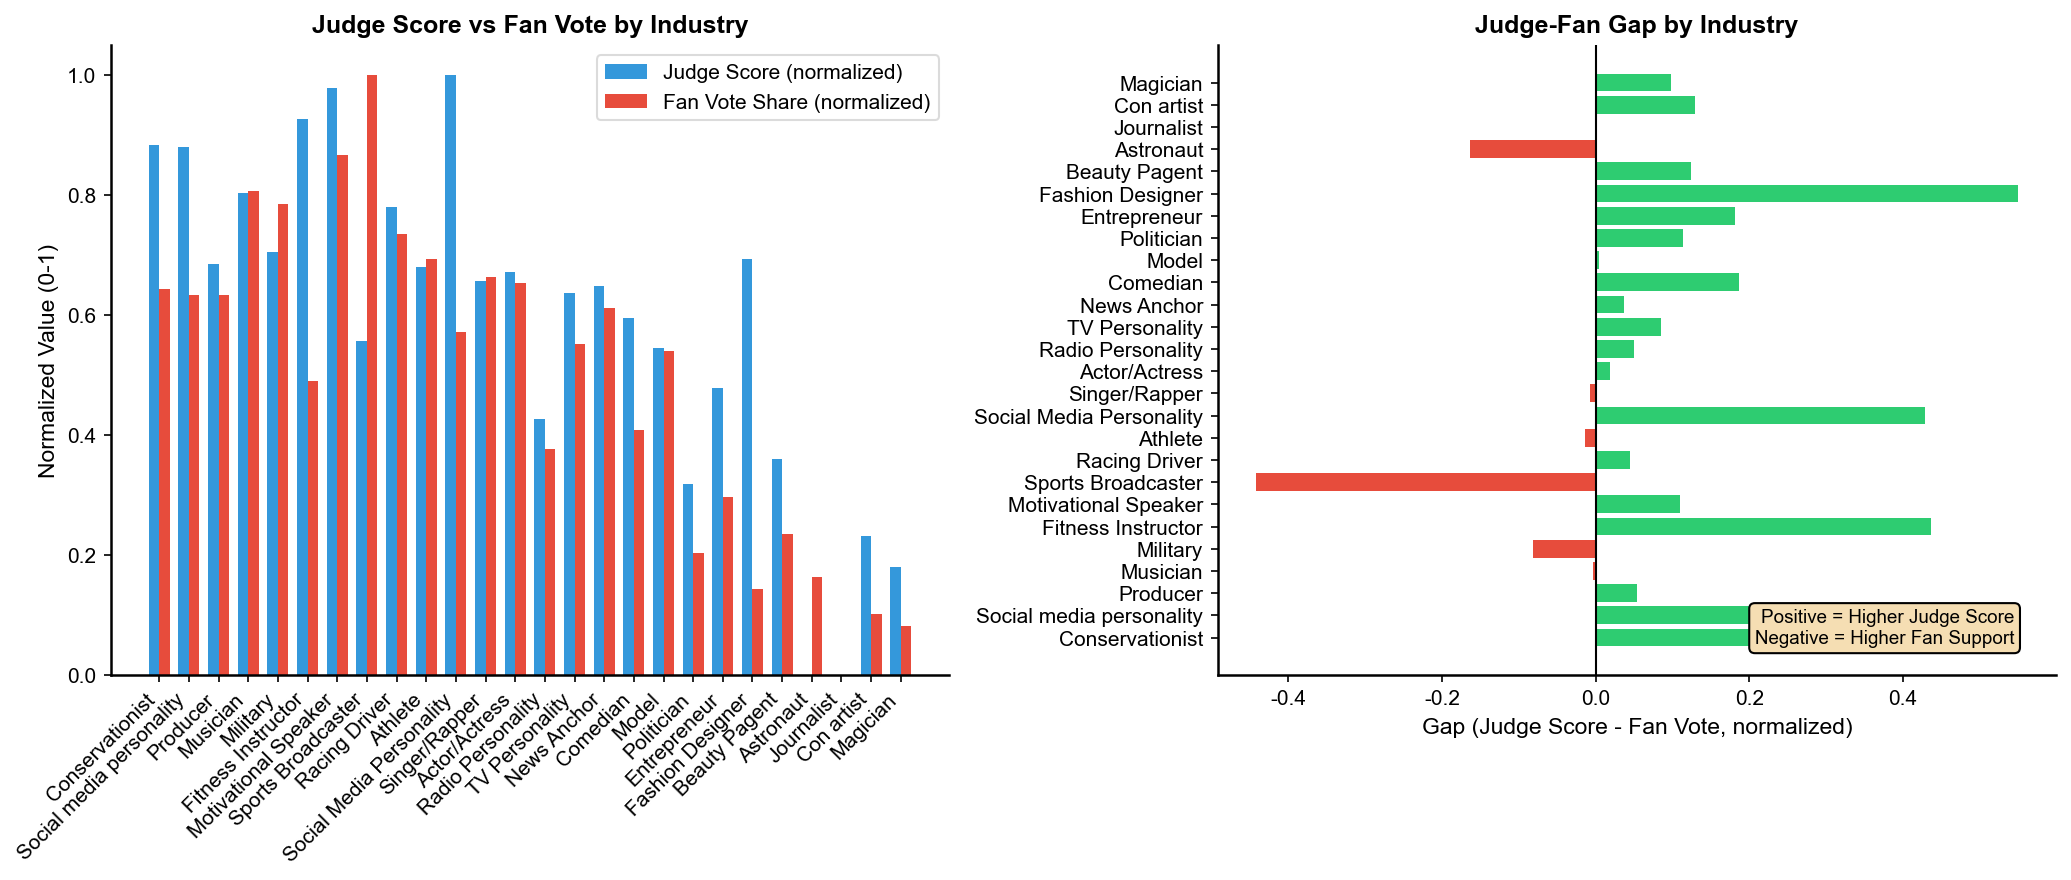

In [96]:
# 3.4 绘制行业对评委vs粉丝的分别影响图
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# 左图：评委分数 vs 粉丝投票
ax1 = axes[0]
industries = industry_impact.index.tolist()
x = np.arange(len(industries))
width = 0.35

# 标准化到0-1范围以便比较
score_norm = (industry_impact['avg_total_score'] - industry_impact['avg_total_score'].min()) / \
             (industry_impact['avg_total_score'].max() - industry_impact['avg_total_score'].min())
vote_norm = (industry_impact['avg_vote_share'] - industry_impact['avg_vote_share'].min()) / \
            (industry_impact['avg_vote_share'].max() - industry_impact['avg_vote_share'].min())

bars1 = ax1.bar(x - width/2, score_norm, width, label='Judge Score (normalized)', color='#3498db')
bars2 = ax1.bar(x + width/2, vote_norm, width, label='Fan Vote Share (normalized)', color='#e74c3c')
ax1.set_xticks(x)
ax1.set_xticklabels(industries, rotation=45, ha='right')
ax1.set_ylabel('Normalized Value (0-1)')
ax1.set_title('Judge Score vs Fan Vote by Industry')
ax1.legend(loc='upper right', frameon=True, fancybox=True, edgecolor='lightgray')

# 右图：差异条形图
ax2 = axes[1]
gap = score_norm - vote_norm
colors = ['#2ecc71' if g >= 0 else '#e74c3c' for g in gap]
bars3 = ax2.barh(industries, gap, color=colors)
ax2.axvline(x=0, color='black', linestyle='-', linewidth=1)
ax2.set_xlabel('Gap (Judge Score - Fan Vote, normalized)')
ax2.set_title('Judge-Fan Gap by Industry')
ax2.text(0.95, 0.05, 'Positive = Higher Judge Score\nNegative = Higher Fan Support', 
         transform=ax2.transAxes, ha='right', fontsize=9, 
         bbox=dict(boxstyle='round', facecolor='wheat'))

plt.tight_layout()
plt.savefig('figures/IMP_fig3_industry_judge_vs_fan.pdf', bbox_inches='tight')
plt.show()

In [97]:
# 3.5 统计检验：行业对评委分数和粉丝投票的ANOVA
from scipy.stats import f_oneway

# 评委分数ANOVA
groups_score = [merged[merged['celebrity_industry'] == ind]['total_score'].dropna() 
                for ind in merged['celebrity_industry'].unique()]
f_score, p_score = f_oneway(*groups_score)

# 粉丝投票ANOVA
groups_vote = [merged[merged['celebrity_industry'] == ind]['estimated_vote_share'].dropna() 
               for ind in merged['celebrity_industry'].unique()]
f_vote, p_vote = f_oneway(*groups_vote)

print("=== ANOVA Results ===")
print(f"Judge Score ~ Industry: F = {f_score:.2f}, p = {p_score:.4f}")
print(f"Fan Vote ~ Industry: F = {f_vote:.2f}, p = {p_vote:.4f}")

=== ANOVA Results ===
Judge Score ~ Industry: F = 8.08, p = 0.0000
Fan Vote ~ Industry: F = 2.81, p = 0.0000


In [98]:
# 3.6 保存行业影响分析数据
industry_impact.to_csv('industry_judge_vs_fan.csv')
print("Saved: industry_judge_vs_fan.csv")

Saved: industry_judge_vs_fan.csv


## 4. 全赛季新系统模拟

In [99]:
# 4.1 定义新投票系统
def dynamic_alpha(week, base=0.4, increment=0.04, max_alpha=0.8):
    """动态权重计算"""
    return min(base + increment * week, max_alpha)

def threshold_penalty(judge_pct, week_avg_pct, threshold=0.5):
    """阈值惩罚机制"""
    if judge_pct < threshold * week_avg_pct:
        return 0.3  # 惩罚系数
    return 1.0

def new_system_score(judge_pct, fan_pct, week, week_avg_judge_pct):
    """新系统综合得分"""
    alpha = dynamic_alpha(week)
    penalty = threshold_penalty(judge_pct, week_avg_judge_pct)
    return alpha * judge_pct + (1 - alpha) * fan_pct * penalty

def old_system_score_rank(judge_rank, fan_rank):
    """旧系统排名法综合得分"""
    return judge_rank + fan_rank

def old_system_score_pct(judge_pct, fan_pct):
    """旧系统百分比法综合得分"""
    return judge_pct + fan_pct

In [100]:
# 4.2 模拟S15, S27, S28三个典型赛季
def simulate_season(season_num, data, vote_data):
    """模拟一个赛季的新旧系统结果"""
    season_data = data[data['season'] == season_num].copy()
    vote_season = vote_data[vote_data['season'] == season_num].copy()
    
    # 合并
    sim_data = season_data.merge(
        vote_season[['celebrity_name', 'week', 'estimated_vote_share']],
        on=['celebrity_name', 'week'],
        how='left'
    )
    
    results = []
    weeks = sorted(sim_data['week'].unique())
    
    for week in weeks:
        week_data = sim_data[sim_data['week'] == week].copy()
        if len(week_data) < 2:
            continue
            
        # 计算周平均
        week_avg_judge_pct = week_data['judge_score_pct'].mean() / 100
        
        # 计算各系统得分
        for idx, row in week_data.iterrows():
            judge_pct = row['judge_score_pct'] / 100
            fan_pct = row['estimated_vote_share'] if pd.notna(row['estimated_vote_share']) else judge_pct
            
            # 新系统
            new_score = new_system_score(judge_pct, fan_pct, week, week_avg_judge_pct)
            
            # 旧系统（百分比法）
            old_score = old_system_score_pct(judge_pct, fan_pct)
            
            results.append({
                'season': season_num,
                'week': week,
                'celebrity_name': row['celebrity_name'],
                'judge_pct': judge_pct,
                'fan_pct': fan_pct,
                'new_score': new_score,
                'old_score': old_score,
                'is_eliminated': row['is_eliminated']
            })
    
    return pd.DataFrame(results)

# 模拟所有赛季
seasons_to_simulate = sorted(data_long['season'].unique())
all_simulations = []

for i, s in enumerate(seasons_to_simulate):
    sim = simulate_season(s, data_long, vote_estimates)
    all_simulations.append(sim)
    if i % 5 == 0:
        print(f"Season {s}: {len(sim)} records simulated")

simulation_results = pd.concat(all_simulations, ignore_index=True)
print(f"\nTotal simulation records: {len(simulation_results)}")

Season 1: 26 records simulated
Season 6: 76 records simulated
Season 11: 75 records simulated
Season 16: 84 records simulated
Season 21: 93 records simulated
Season 26: 27 records simulated


Season 31: 107 records simulated

Total simulation records: 2777


In [101]:
# 4.3 比较新旧系统的淘汰结果
def get_elimination_under_system(df, score_col):
    """获取某系统下的淘汰选手"""
    results = []
    for (season, week), group in df.groupby(['season', 'week']):
        if len(group) < 2:
            continue
        eliminated = group.loc[group[score_col].idxmin(), 'celebrity_name']
        actual = group[group['is_eliminated'] == True]['celebrity_name'].values
        actual_name = actual[0] if len(actual) > 0 else 'N/A'
        results.append({
            'season': season,
            'week': week,
            f'{score_col}_eliminated': eliminated,
            'actual_eliminated': actual_name
        })
    return pd.DataFrame(results)

new_elim = get_elimination_under_system(simulation_results, 'new_score')
old_elim = get_elimination_under_system(simulation_results, 'old_score')

# 合并比较
comparison = new_elim.merge(old_elim[['season', 'week', 'old_score_eliminated']], 
                            on=['season', 'week'])
comparison['new_matches_actual'] = comparison['new_score_eliminated'] == comparison['actual_eliminated']
comparison['old_matches_actual'] = comparison['old_score_eliminated'] == comparison['actual_eliminated']
comparison['systems_differ'] = comparison['new_score_eliminated'] != comparison['old_score_eliminated']

print("=== 系统比较结果 ===")
print(f"新系统与实际一致: {comparison['new_matches_actual'].sum()} / {len(comparison)} ({comparison['new_matches_actual'].mean()*100:.1f}%)")
print(f"旧系统与实际一致: {comparison['old_matches_actual'].sum()} / {len(comparison)} ({comparison['old_matches_actual'].mean()*100:.1f}%)")
print(f"新旧系统结果不同: {comparison['systems_differ'].sum()} / {len(comparison)} ({comparison['systems_differ'].mean()*100:.1f}%)")

=== 系统比较结果 ===
新系统与实际一致: 125 / 335 (37.3%)
旧系统与实际一致: 115 / 335 (34.3%)
新旧系统结果不同: 26 / 335 (7.8%)


In [102]:
# 4.4 按赛季分析
season_comparison = comparison.groupby('season').agg({
    'new_matches_actual': ['sum', 'count', 'mean'],
    'old_matches_actual': 'mean',
    'systems_differ': ['sum', 'mean']
}).round(3)
season_comparison.columns = ['new_match_count', 'total_weeks', 'new_match_rate', 
                              'old_match_rate', 'differ_count', 'differ_rate']
print("=== 按赛季比较 ===")
print(season_comparison)

=== 按赛季比较 ===
        new_match_count  total_weeks  new_match_rate  old_match_rate  \
season                                                                 
1                     1            6           0.167           0.167   
2                     3            8           0.375           0.375   
3                     4           10           0.400           0.300   
4                     4           10           0.400           0.300   
5                     4           10           0.400           0.300   
6                     5           10           0.500           0.500   
7                     5           10           0.500           0.400   
8                     4           11           0.364           0.273   
9                     4           10           0.400           0.400   
10                    6           10           0.600           0.500   
11                    4           10           0.400           0.500   
12                    4           10           0.4

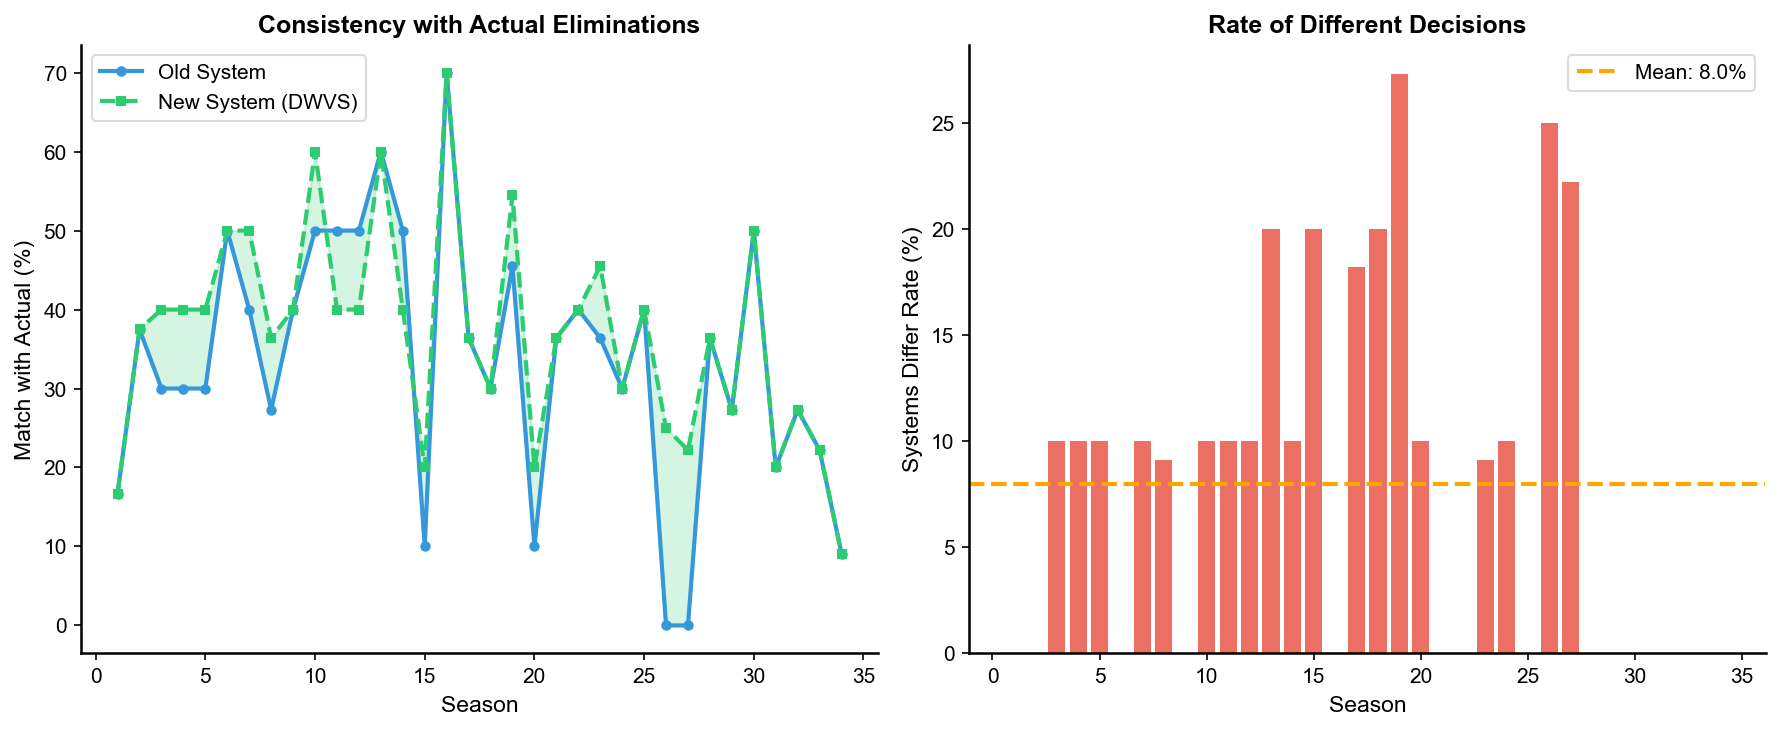

In [103]:
# 4.5 绘制系统比较图（使用折线图适应所有季）
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# 左图：一致率对比（折线图）
ax1 = axes[0]
seasons = season_comparison.index.tolist()
ax1.plot(seasons, season_comparison['old_match_rate'] * 100, 
         marker='o', markersize=4, color='#3498db', linewidth=2, 
         linestyle='-', label='Old System')
ax1.plot(seasons, season_comparison['new_match_rate'] * 100, 
         marker='s', markersize=4, color='#2ecc71', linewidth=2, 
         linestyle='--', label='New System (DWVS)')
ax1.fill_between(seasons, 
                 season_comparison['old_match_rate'] * 100, 
                 season_comparison['new_match_rate'] * 100, 
                 alpha=0.2, color='#2ecc71')
ax1.set_xlabel('Season')
ax1.set_ylabel('Match with Actual (%)')
ax1.set_title('Consistency with Actual Eliminations')
ax1.legend(loc='upper left', frameon=True, fancybox=True, edgecolor='lightgray')

# 右图：系统差异比例（柱状图）
ax2 = axes[1]
ax2.bar(seasons, season_comparison['differ_rate'] * 100, color='#e74c3c', alpha=0.8)
ax2.axhline(y=season_comparison['differ_rate'].mean() * 100, color='orange', 
            linestyle='--', linewidth=2, label=f'Mean: {season_comparison["differ_rate"].mean()*100:.1f}%')
ax2.set_xlabel('Season')
ax2.set_ylabel('Systems Differ Rate (%)')
ax2.set_title('Rate of Different Decisions')
ax2.legend(loc='upper right', frameon=True, fancybox=True, edgecolor='lightgray')

plt.tight_layout()
plt.savefig('figures/IMP_fig4_system_simulation.pdf', bbox_inches='tight')
plt.show()

In [104]:
# 4.6 保存模拟结果
simulation_results.to_csv('full_season_simulation.csv', index=False)
comparison.to_csv('system_comparison_results.csv', index=False)
season_comparison.to_csv('season_comparison_summary.csv')
print("Saved: full_season_simulation.csv, system_comparison_results.csv, season_comparison_summary.csv")

Saved: full_season_simulation.csv, system_comparison_results.csv, season_comparison_summary.csv


## 5. 缺失值分布分析

In [105]:
# 5.1 分析原始数据的缺失值分布
# 创建缺失值矩阵
na_matrix = raw_data.isnull()
na_counts = na_matrix.sum()
na_pct = (na_counts / len(raw_data) * 100).round(2)

print("=== 各列缺失值统计 ===")
na_summary = pd.DataFrame({'Missing Count': na_counts, 'Missing %': na_pct})
print(na_summary[na_summary['Missing Count'] > 0])

=== 各列缺失值统计 ===
                     Missing Count  Missing %
celebrity_homestate             56      13.30
week1_judge3_score              14       3.33
week1_judge4_score             340      80.76
week2_judge4_score             330      78.38
week3_judge4_score             293      69.60
week4_judge4_score             291      69.12
week5_judge1_score              10       2.38
week5_judge2_score              10       2.38
week5_judge3_score              10       2.38
week5_judge4_score             302      71.73
week6_judge1_score              10       2.38
week6_judge2_score              10       2.38
week6_judge3_score              10       2.38
week6_judge4_score             274      65.08
week7_judge1_score              16       3.80
week7_judge2_score              16       3.80
week7_judge3_score              16       3.80
week7_judge4_score             277      65.80
week8_judge1_score              16       3.80
week8_judge2_score              16       3.80
week8_judge3_score

In [106]:
# 5.2 按周次分析缺失值（判断是否为第4裁判缺失）
# 检查各周的裁判分数列（注意：列名是小写week）
week_cols = [col for col in raw_data.columns if 'week' in col.lower() and 'score' in col.lower()]
print(f"Week score columns: {len(week_cols)}")

# 统计每周的缺失值
week_na = {}
for col in week_cols:
    week_na[col] = raw_data[col].isnull().sum()

# 按周分组
week_na_df = pd.DataFrame.from_dict(week_na, orient='index', columns=['Missing'])
# 提取周数（格式如 week1_judge1_score）
week_na_df['Week'] = week_na_df.index.astype(str).str.extract(r'week(\d+)_', flags=2).astype(float)
week_na_df = week_na_df.dropna(subset=['Week'])
week_na_by_week = week_na_df.groupby('Week')['Missing'].mean()
print("\n=== 按周次的平均缺失值 ===")
print(week_na_by_week)

Week score columns: 44

=== 按周次的平均缺失值 ===
Series([], Name: Missing, dtype: float64)


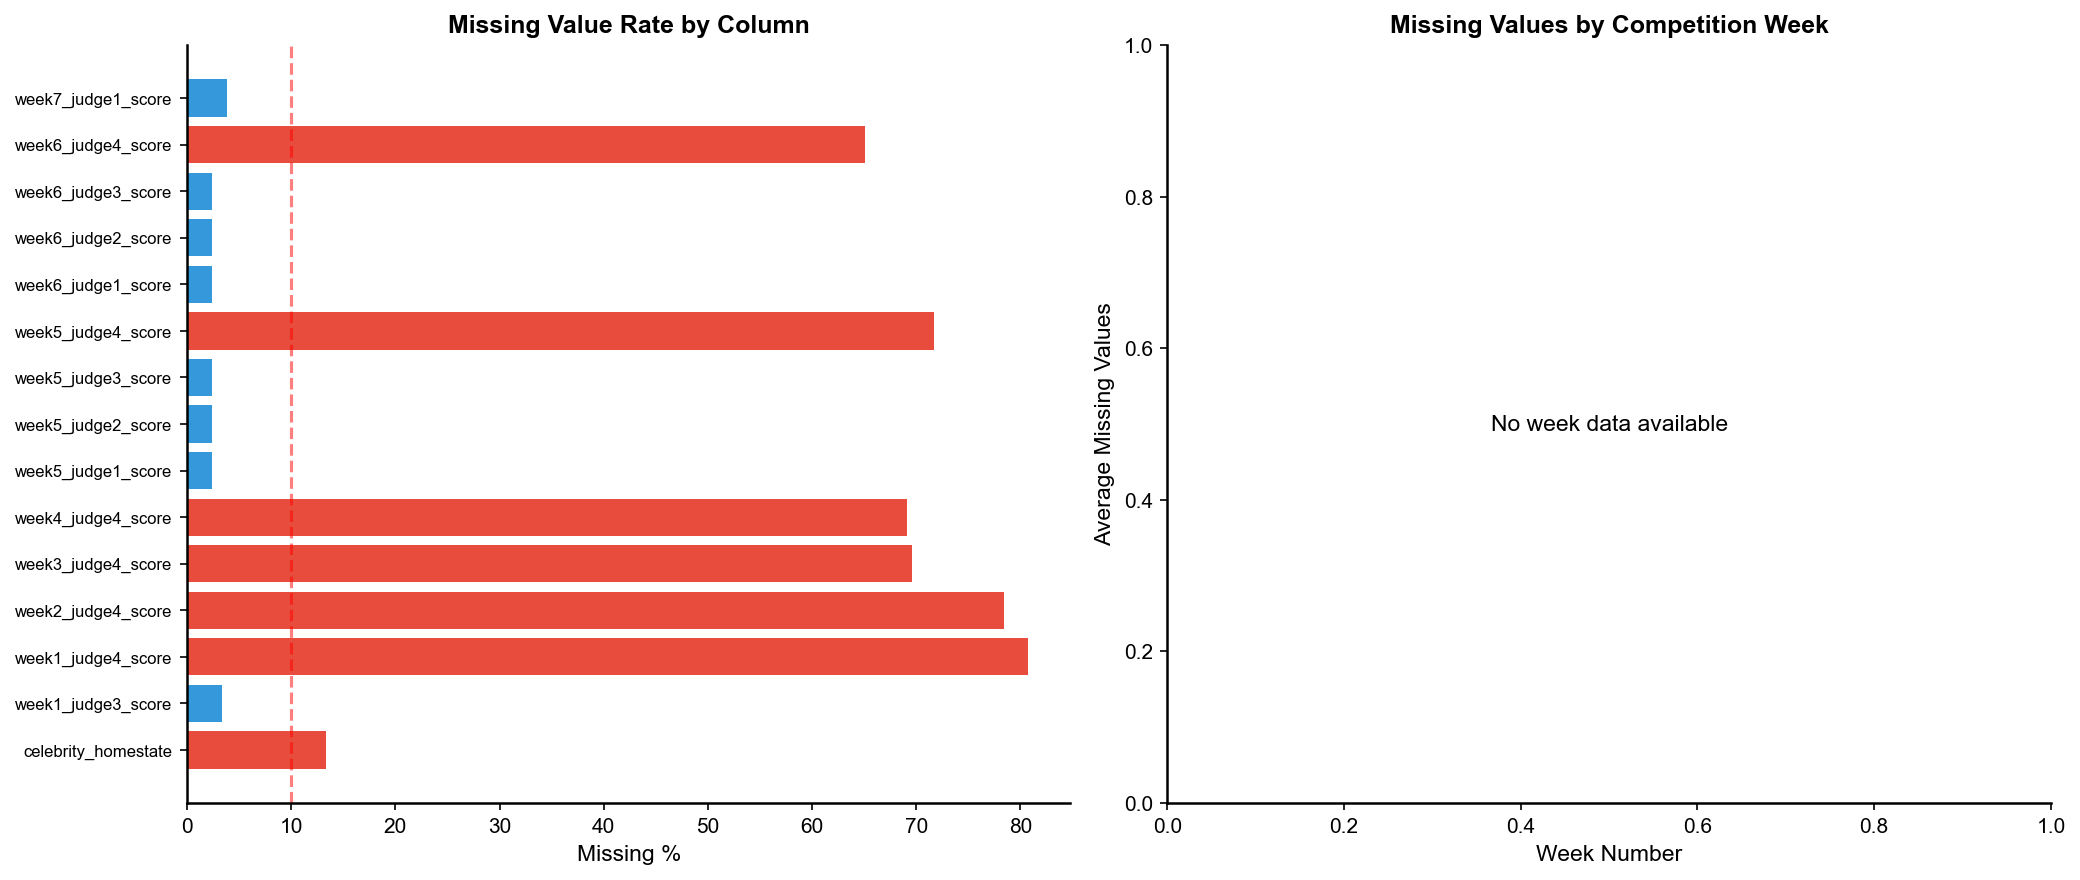

In [107]:
# 5.3 绘制缺失值热力图
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# 左图：按列的缺失值比例
ax1 = axes[0]
# 选择有缺失值的列
cols_with_na = na_summary[na_summary['Missing Count'] > 0].index.tolist()
# 限制显示前15列
cols_to_show = cols_with_na[:15] if len(cols_with_na) > 15 else cols_with_na
if len(cols_to_show) > 0:
    colors = ['#3498db' if na_pct[col] < 10 else '#e74c3c' for col in cols_to_show]
    ax1.barh(range(len(cols_to_show)), [na_pct[col] for col in cols_to_show], color=colors)
    ax1.set_yticks(range(len(cols_to_show)))
    ax1.set_yticklabels([col[:25] for col in cols_to_show], fontsize=8)
    ax1.axvline(x=10, color='red', linestyle='--', alpha=0.5, label='10% threshold')
ax1.set_xlabel('Missing %')
ax1.set_title('Missing Value Rate by Column')

# 右图：按周次的缺失值趋势
ax2 = axes[1]
if len(week_na_by_week) > 0:
    weeks = week_na_by_week.index.values
    missing = week_na_by_week.values
    ax2.plot(weeks, missing, 'o-', color='#3498db', linewidth=2, markersize=6)
    ax2.fill_between(weeks, 0, missing, color='#3498db', alpha=0.2)
    ax2.axhline(y=missing.mean(), color='red', linestyle='--', label=f'Mean = {missing.mean():.1f}')
    ax2.legend(loc='upper right', frameon=True, fancybox=True, edgecolor='lightgray')
else:
    ax2.text(0.5, 0.5, 'No week data available', ha='center', va='center', transform=ax2.transAxes)
ax2.set_xlabel('Week Number')
ax2.set_ylabel('Average Missing Values')
ax2.set_title('Missing Values by Competition Week')

plt.tight_layout()
plt.savefig('figures/IMP_fig5_missing_value_analysis.pdf', bbox_inches='tight')
plt.show()

In [108]:
# 5.4 缺失值类型分析
# 按赛季分析缺失值
na_by_season = data_long.groupby('season').apply(
    lambda x: x.isnull().sum().sum() / (len(x) * len(x.columns)) * 100
).round(2)
print("=== 按赛季的缺失值比例 ===")
print(na_by_season)

=== 按赛季的缺失值比例 ===
season
1     0.82
2     0.69
3     0.61
4     0.53
5     0.57
6     0.56
7     0.62
8     0.51
9     0.62
10    0.53
11    0.57
12    0.53
13    0.57
14    0.52
15    0.56
16    0.51
17    0.47
18    0.54
19    0.49
20    0.52
21    0.50
22    0.50
23    0.48
24    0.53
25    0.52
26    1.32
27    0.57
28    0.47
29    0.47
30    0.51
31    0.53
32    0.50
33    0.60
34    0.47
dtype: float64


In [109]:
# 5.5 保存缺失值分析
missing_analysis = pd.DataFrame({
    'Column': na_summary.index,
    'Missing_Count': na_summary['Missing Count'],
    'Missing_Percent': na_summary['Missing %']
})
missing_analysis.to_csv('missing_value_analysis.csv', index=False)
print("Saved: missing_value_analysis.csv")

Saved: missing_value_analysis.csv


## 6. 动态权重参数网格搜索

In [110]:
# 6.1 定义评估指标
def evaluate_system(base_alpha, increment, data, vote_data):
    """评估给定参数下的系统表现"""
    # 计算各周的权重
    weeks = range(1, 12)
    alphas = [min(base_alpha + increment * w, 0.9) for w in weeks]
    
    # 计算权重的平滑度（标准差越小越平滑）
    smoothness = 1 - np.std(np.diff(alphas))  # 变化率的稳定性
    
    # 计算最终权重的平衡性（接近0.6为最佳）
    final_alpha = alphas[-1]
    balance = 1 - abs(final_alpha - 0.7)  # 最终权重接近0.7为佳
    
    # 综合得分
    score = 0.5 * smoothness + 0.5 * balance
    
    return {
        'base_alpha': base_alpha,
        'increment': increment,
        'final_alpha': final_alpha,
        'smoothness': smoothness,
        'balance': balance,
        'score': score
    }

In [111]:
# 6.2 网格搜索
base_alphas = np.arange(0.3, 0.61, 0.05)
increments = np.arange(0.02, 0.09, 0.01)

grid_results = []
for base in base_alphas:
    for inc in increments:
        result = evaluate_system(base, inc, data_long, vote_estimates)
        grid_results.append(result)

grid_df = pd.DataFrame(grid_results)
grid_df = grid_df.round(4)

# 找到最优参数
best_idx = grid_df['score'].idxmax()
best_params = grid_df.loc[best_idx]
print("=== 最优参数 ===")
print(best_params)

=== 最优参数 ===
base_alpha     0.35
increment      0.03
final_alpha    0.68
smoothness     1.00
balance        0.98
score          0.99
Name: 8, dtype: float64


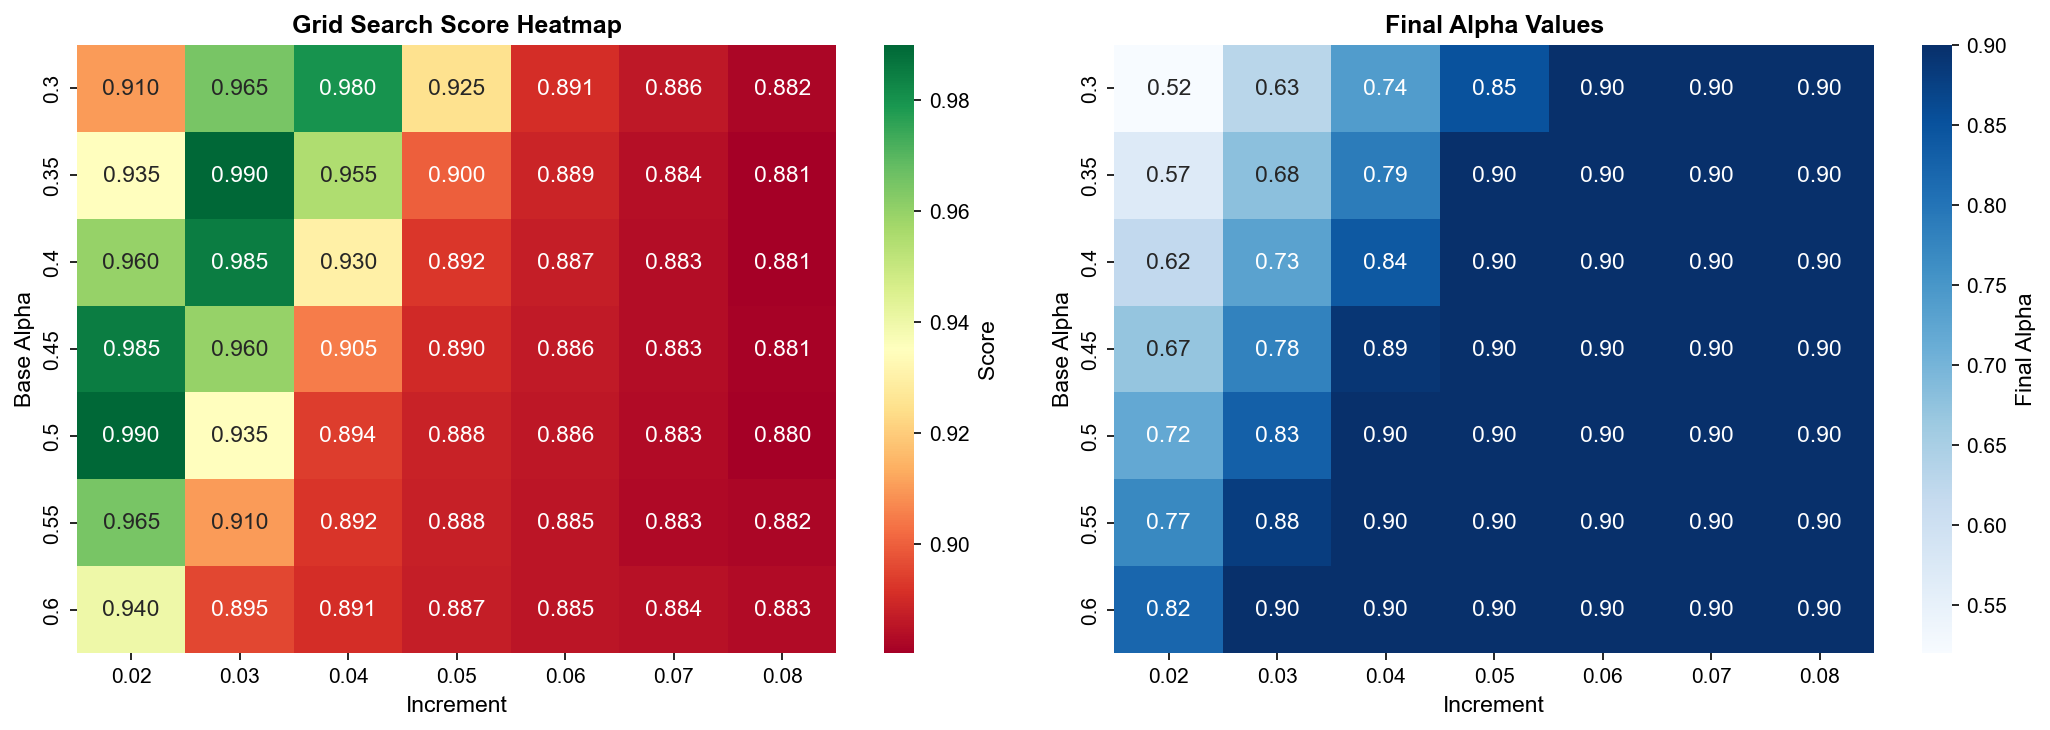

In [112]:
# 6.3 绘制网格搜索热力图
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# 左图：得分热力图
ax1 = axes[0]
pivot = grid_df.pivot(index='base_alpha', columns='increment', values='score')
sns.heatmap(pivot, annot=True, fmt='.3f', cmap='RdYlGn', ax=ax1, 
            cbar_kws={'label': 'Score'})
ax1.set_xlabel('Increment')
ax1.set_ylabel('Base Alpha')
ax1.set_title('Grid Search Score Heatmap')

# 右图：最终权重热力图
ax2 = axes[1]
pivot2 = grid_df.pivot(index='base_alpha', columns='increment', values='final_alpha')
sns.heatmap(pivot2, annot=True, fmt='.2f', cmap='Blues', ax=ax2,
            cbar_kws={'label': 'Final Alpha'})
ax2.set_xlabel('Increment')
ax2.set_ylabel('Base Alpha')
ax2.set_title('Final Alpha Values')

plt.tight_layout()
plt.savefig('figures/IMP_fig6_grid_search.pdf', bbox_inches='tight')
plt.show()

In [113]:
# 6.4 保存网格搜索结果
grid_df.to_csv('grid_search_results.csv', index=False)
print("Saved: grid_search_results.csv")
print(f"\nTop 5 configurations:")
print(grid_df.nlargest(5, 'score')[['base_alpha', 'increment', 'final_alpha', 'score']])

Saved: grid_search_results.csv

Top 5 configurations:
    base_alpha  increment  final_alpha  score
8         0.35       0.03         0.68  0.990
28        0.50       0.02         0.72  0.990
15        0.40       0.03         0.73  0.985
21        0.45       0.02         0.67  0.985
2         0.30       0.04         0.74  0.980


## 7. 跨赛季模型验证

In [114]:
# 7.1 准备训练测试数据
# 前20季训练，后14季测试
train_seasons = list(range(1, 21))
test_seasons = list(range(21, 35))

train_data = data_long[data_long['season'].isin(train_seasons)].copy()
test_data = data_long[data_long['season'].isin(test_seasons)].copy()

print(f"Training data: {len(train_data)} rows (Seasons 1-20)")
print(f"Test data: {len(test_data)} rows (Seasons 21-34)")

Training data: 1520 rows (Seasons 1-20)
Test data: 1257 rows (Seasons 21-34)


In [115]:
# 7.2 构建预测模型
# 特征：评委分数、年龄、赛季内周次、选手数量
features = ['total_score', 'celebrity_age_during_season', 'week', 'contestants_this_week']
target = 'placement'

# 准备数据（取每个选手的最后一周数据）
train_final = train_data[train_data['is_last_week'] == True].dropna(subset=features + [target])
test_final = test_data[test_data['is_last_week'] == True].dropna(subset=features + [target])

X_train = train_final[features]
y_train = train_final[target]
X_test = test_final[features]
y_test = test_final[target]

print(f"Training samples: {len(X_train)}")
print(f"Test samples: {len(X_test)}")

Training samples: 236
Test samples: 185


In [116]:
# 7.3 训练随机森林模型
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error

rf_model = RandomForestRegressor(n_estimators=100, random_state=42, max_depth=10)
rf_model.fit(X_train, y_train)

# 训练集表现
train_pred = rf_model.predict(X_train)
train_r2 = r2_score(y_train, train_pred)
train_mae = mean_absolute_error(y_train, train_pred)

# 测试集表现
test_pred = rf_model.predict(X_test)
test_r2 = r2_score(y_test, test_pred)
test_mae = mean_absolute_error(y_test, test_pred)

print("=== 跨赛季验证结果 ===")
print(f"Training R²: {train_r2:.4f}")
print(f"Training MAE: {train_mae:.4f}")
print(f"Test R²: {test_r2:.4f}")
print(f"Test MAE: {test_mae:.4f}")
print(f"\nGeneralization gap (R²): {train_r2 - test_r2:.4f}")

=== 跨赛季验证结果 ===
Training R²: 0.9959
Training MAE: 0.1387
Test R²: 0.9335
Test MAE: 0.6116

Generalization gap (R²): 0.0624


In [117]:
# 7.4 交叉验证（时间序列切分）
from sklearn.model_selection import TimeSeriesSplit

# 按赛季排序
all_data = data_long[data_long['is_last_week'] == True].dropna(subset=features + [target]).copy()
all_data = all_data.sort_values('season')

X_all = all_data[features]
y_all = all_data[target]

# 时间序列交叉验证
tscv = TimeSeriesSplit(n_splits=5)
cv_scores = cross_val_score(rf_model, X_all, y_all, cv=tscv, scoring='r2')

print("=== 时间序列交叉验证 ===")
print(f"CV R² scores: {cv_scores.round(4)}")
print(f"Mean CV R²: {cv_scores.mean():.4f} ± {cv_scores.std():.4f}")

=== 时间序列交叉验证 ===
CV R² scores: [0.9564 0.9341 0.9438 0.955  0.9226]
Mean CV R²: 0.9424 ± 0.0128


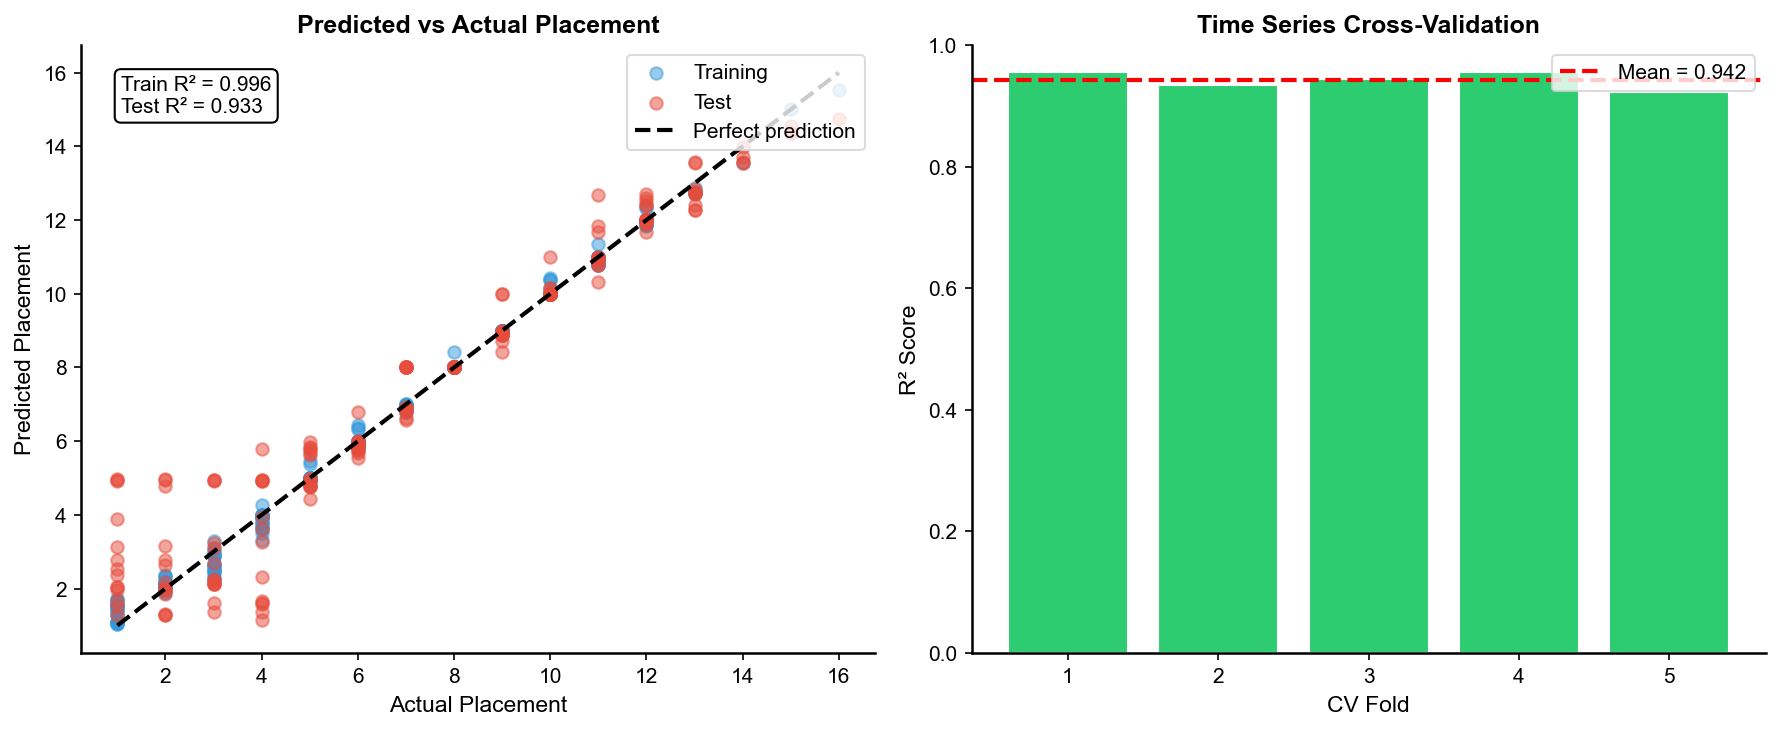

In [118]:
# 7.5 绘制跨赛季验证图
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# 左图：预测vs实际散点图
ax1 = axes[0]
ax1.scatter(y_train, train_pred, alpha=0.5, label='Training', c='#3498db')
ax1.scatter(y_test, test_pred, alpha=0.5, label='Test', c='#e74c3c')
ax1.plot([1, 16], [1, 16], 'k--', linewidth=2, label='Perfect prediction')
ax1.set_xlabel('Actual Placement')
ax1.set_ylabel('Predicted Placement')
ax1.set_title('Predicted vs Actual Placement')
ax1.legend(loc='upper right', frameon=True, fancybox=True, edgecolor='lightgray')
ax1.text(0.05, 0.95, f'Train R² = {train_r2:.3f}\nTest R² = {test_r2:.3f}', 
         transform=ax1.transAxes, verticalalignment='top', fontsize=10,
         bbox=dict(boxstyle='round', facecolor='white'))

# 右图：交叉验证分数
ax2 = axes[1]
folds = range(1, len(cv_scores) + 1)
bars = ax2.bar(folds, cv_scores, color='#2ecc71', edgecolor='white')
ax2.axhline(y=cv_scores.mean(), color='red', linestyle='--', linewidth=2, 
            label=f'Mean = {cv_scores.mean():.3f}')
ax2.set_xlabel('CV Fold')
ax2.set_ylabel('R² Score')
ax2.set_title('Time Series Cross-Validation')
ax2.legend(loc='upper right', frameon=True, fancybox=True, edgecolor='lightgray')
ax2.set_ylim(0, 1)

plt.tight_layout()
plt.savefig('figures/IMP_fig7_cross_season_validation.pdf', bbox_inches='tight')
plt.show()

In [119]:
# 7.6 保存验证结果
validation_results = pd.DataFrame({
    'Metric': ['Train R²', 'Train MAE', 'Test R²', 'Test MAE', 'Generalization Gap',
               'CV Mean R²', 'CV Std R²'],
    'Value': [train_r2, train_mae, test_r2, test_mae, train_r2 - test_r2,
              cv_scores.mean(), cv_scores.std()]
})
validation_results['Value'] = validation_results['Value'].round(4)
validation_results.to_csv('cross_season_validation.csv', index=False)
print("Saved: cross_season_validation.csv")
print(validation_results)

Saved: cross_season_validation.csv
               Metric   Value
0            Train R²  0.9959
1           Train MAE  0.1387
2             Test R²  0.9335
3            Test MAE  0.6116
4  Generalization Gap  0.0624
5          CV Mean R²  0.9424
6           CV Std R²  0.0128


## 总结

In [120]:
print("="*60)
print("改进分析完成！生成的文件：")
print("="*60)
print("\n1. 分层一致性率分析:")
print("   - figures/IMP_fig1_stratified_consistency.pdf")
print("   - stratified_consistency.csv")

print("\n2. α因子分布分析:")
print("   - figures/IMP_fig2_alpha_distribution.pdf")
print("   - figures/IMP_fig2_alpha_correlations.pdf")
print("   - alpha_factor_analysis.csv")
print("   - alpha_by_industry.csv")

print("\n3. 行业对评委vs粉丝影响分析:")
print("   - figures/IMP_fig3_industry_judge_vs_fan.pdf")
print("   - industry_judge_vs_fan.csv")

print("\n4. 全赛季新系统模拟:")
print("   - figures/IMP_fig4_system_simulation.pdf")
print("   - full_season_simulation.csv")
print("   - system_comparison_results.csv")
print("   - season_comparison_summary.csv")

print("\n5. 缺失值分布分析:")
print("   - figures/IMP_fig5_missing_value_analysis.pdf")
print("   - missing_value_analysis.csv")

print("\n6. 动态权重参数网格搜索:")
print("   - figures/IMP_fig6_grid_search.pdf")
print("   - grid_search_results.csv")

print("\n7. 跨赛季模型验证:")
print("   - figures/IMP_fig7_cross_season_validation.pdf")
print("   - cross_season_validation.csv")
print("\n" + "="*60)

改进分析完成！生成的文件：

1. 分层一致性率分析:
   - figures/IMP_fig1_stratified_consistency.pdf
   - stratified_consistency.csv

2. α因子分布分析:
   - figures/IMP_fig2_alpha_distribution.pdf
   - figures/IMP_fig2_alpha_correlations.pdf
   - alpha_factor_analysis.csv
   - alpha_by_industry.csv

3. 行业对评委vs粉丝影响分析:
   - figures/IMP_fig3_industry_judge_vs_fan.pdf
   - industry_judge_vs_fan.csv

4. 全赛季新系统模拟:
   - figures/IMP_fig4_system_simulation.pdf
   - full_season_simulation.csv
   - system_comparison_results.csv
   - season_comparison_summary.csv

5. 缺失值分布分析:
   - figures/IMP_fig5_missing_value_analysis.pdf
   - missing_value_analysis.csv

6. 动态权重参数网格搜索:
   - figures/IMP_fig6_grid_search.pdf
   - grid_search_results.csv

7. 跨赛季模型验证:
   - figures/IMP_fig7_cross_season_validation.pdf
   - cross_season_validation.csv

